Shape of dataset: (300, 3)
First 5 samples:
 [[-1.24335878 -0.46147292 -0.56680536]
 [-2.82736836 -2.45918053 -1.94079829]
 [-2.94781017 -3.09864005 -1.19105824]
 [-0.78896445 -0.87173356 -1.07703213]
 [ 0.53765581 -0.2830132  -2.17950461]]


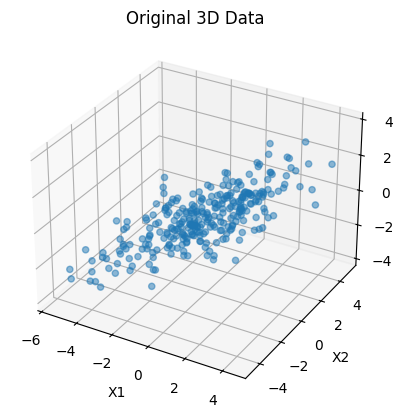

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

# Mean vector
mean = [0, 0, 0]

# Covariance matrix (introducing correlation)
cov = [
    [4, 3, 2],
    [3, 3, 1.5],
    [2, 1.5, 2]
]

# Generate 3D correlated dataset
X = np.random.multivariate_normal(mean, cov, 300)

print("Shape of dataset:", X.shape)
print("First 5 samples:\n", X[:5])

# 3D Scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], alpha=0.5)
ax.set_title("Original 3D Data")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")
plt.show()

In [59]:
import plotly.express as px
import pandas as pd

mean_vector = np.mean(X, axis=0)
X_centered = X - mean_vector
df_3D_plot = pd.DataFrame(X_centered, columns=["X1", "X2", "X3"])

fig = px.scatter_3d(
    df_3D_plot,
    x="X1",
    y="X2",
    z="X3",
    opacity=0.6,
    title="Interactive 3D Data"
)

fig.show()

In [46]:
# Compute mean of each feature
mean_vector = np.mean(X, axis=0)
print("Mean vector:", mean_vector)

# Center the data
X_centered = X - mean_vector

# Verify mean is ~0 after centering
print("Mean after centering:", np.mean(X_centered, axis=0))

Mean vector: [-0.14964161 -0.04867148 -0.12741902]
Mean after centering: [-1.43588845e-16 -1.48029737e-17 -1.27675648e-16]


In [47]:
# Number of samples
n = X_centered.shape[0]

# Covariance matrix using formula: (1 / (n - 1)) * X^T X
cov_matrix = (1 / (n - 1)) * np.dot(X_centered.T, X_centered)

print("Covariance Matrix:\n", cov_matrix)
print("Shape:", cov_matrix.shape)

Covariance Matrix:
 [[3.20065549 2.39044818 1.52293362]
 [2.39044818 2.6158278  1.12765344]
 [1.52293362 1.12765344 1.69542587]]
Shape: (3, 3)


In [48]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors (columns):\n", eigenvectors)

Eigenvalues:
 [6.12238996 0.44724989 0.94226931]

Eigenvectors (columns):
 [[ 0.69626886  0.71474552 -0.06594329]
 [ 0.60090185 -0.63067623 -0.49108498]
 [ 0.39258965 -0.30230174  0.86861212]]


In [49]:
# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("Sorted Eigenvalues:\n", eigenvalues_sorted)
print("\nSorted Eigenvectors (columns):\n", eigenvectors_sorted)

Sorted Eigenvalues:
 [6.12238996 0.94226931 0.44724989]

Sorted Eigenvectors (columns):
 [[ 0.69626886 -0.06594329  0.71474552]
 [ 0.60090185 -0.49108498 -0.63067623]
 [ 0.39258965  0.86861212 -0.30230174]]


In [50]:
# Total variance
total_variance = np.sum(eigenvalues_sorted)

# Explained variance ratio
explained_variance_ratio = eigenvalues_sorted / total_variance

print("Explained Variance Ratio:\n", explained_variance_ratio)
print("\nCumulative Explained Variance:\n", np.cumsum(explained_variance_ratio))

Explained Variance Ratio:
 [0.81502449 0.12543673 0.05953878]

Cumulative Explained Variance:
 [0.81502449 0.94046122 1.        ]


In [51]:
# Select top 2 eigenvectors
W_2D = eigenvectors_sorted[:, :2]   # shape (3,2)

print("Projection matrix shape:", W_2D.shape)

# Project data
X_2D = np.dot(X_centered, W_2D)

print("Reduced data shape (3D -> 2D):", X_2D.shape)

Projection matrix shape: (3, 2)
Reduced data shape (3D -> 2D): (300, 2)


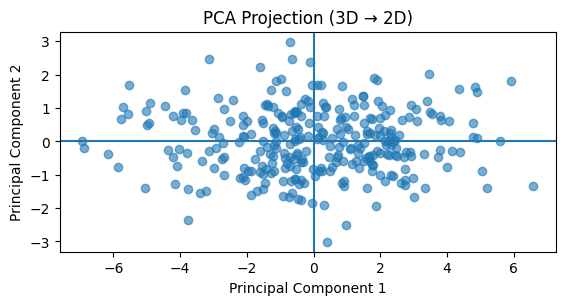

In [52]:
plt.scatter(X_2D[:, 0], X_2D[:, 1], alpha=0.6)
plt.title("PCA Projection (3D → 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.axhline(0)
plt.axvline(0)
plt.gca().set_aspect('equal', 'box')
plt.show()

In [60]:
df_2D_plot = pd.DataFrame(X_2D, columns=["PC1", "PC2"])

fig = px.scatter(
    df_2D_plot,
    x="PC1",
    y="PC2",
    opacity=0.6,
    title="Interactive PCA (3D → 2D)"
)

fig.show()

In [53]:
# Select top 1 eigenvector
W_1D = eigenvectors_sorted[:, :1]   # shape (3,1)

print("Projection matrix shape:", W_1D.shape)

# Project data
X_1D = np.dot(X_centered, W_1D)

print("Reduced data shape (3D -> 1D):", X_1D.shape)

Projection matrix shape: (3, 1)
Reduced data shape (3D -> 1D): (300, 1)


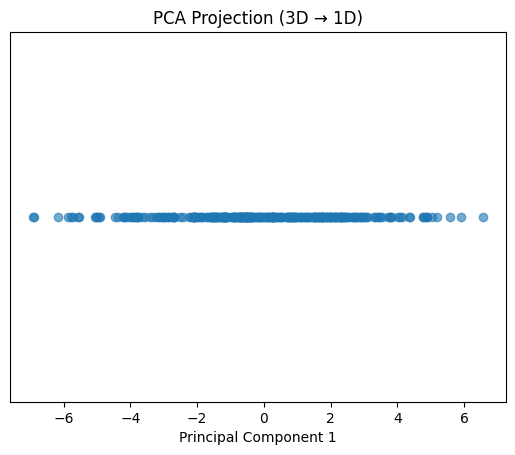

In [54]:
plt.figure()
plt.scatter(X_1D, np.zeros_like(X_1D), alpha=0.6)
plt.title("PCA Projection (3D → 1D)")
plt.xlabel("Principal Component 1")
plt.yticks([])
plt.show()

In [61]:
df_1D_plot = pd.DataFrame(X_1D, columns=["PC1"])
df_1D_plot["zero"] = 0  # fake Y axis for visualization

fig = px.scatter(
    df_1D_plot,
    x="PC1",
    y="zero",
    opacity=0.6,
    title="Interactive PCA (3D → 1D)"
)

fig.update_yaxes(visible=False)
fig.show()

In [55]:
import pandas as pd

df_3D = pd.DataFrame(X_centered, columns=["X1", "X2", "X3"])
df_3D.head(10)

,X1,X2,X3
0,-1.093717,-0.412801,-0.439386
1,-2.677727,-2.410509,-1.813379
2,-2.798169,-3.049969,-1.063639
3,-0.639323,-0.823062,-0.949613
4,0.687297,-0.234342,-2.052086
5,1.219610,1.545533,-0.052889
6,1.416417,2.780407,0.183167
7,1.227154,-0.232196,0.203629
8,1.717283,0.381887,0.641749
9,-0.377702,-0.416830,-0.851058


In [56]:
df_2D = pd.DataFrame(X_2D, columns=["PC1", "PC2"])
df_2D.head(10)

,PC1,PC2
0,-1.182073,-0.106812
1,-4.024811,-0.214780
2,-4.198583,0.758424
3,-1.312528,-0.378493
4,-0.467900,-1.712707
5,1.757126,-0.885353
6,2.728869,-1.299718
7,0.794845,0.209981
8,1.677111,0.256648
9,-0.847572,-0.509633


In [57]:
df_1D = pd.DataFrame(X_1D, columns=["PC1"])
df_1D.head(10)

,PC1
0,-1.182073
1,-4.024811
2,-4.198583
3,-1.312528
4,-0.467900
5,1.757126
6,2.728869
7,0.794845
8,1.677111
9,-0.847572
